## Causal Question
Does using a voucher (treatment_voucher) cause a reduction in churn,
or do we just observe lower churn among voucher users because they were
already more loyal/frequent customers to begin with?

## Variables
- Treatment (T): treatment_voucher (1 = used a voucher at least once, 0 = never)
- Outcome (Y): churned (1 = churned, 0 = retained)
- Confounders (likely common causes of BOTH treatment and outcome):
  - frequency -- frequent shoppers are both more likely to encounter/use a voucher
    AND more likely to be retained regardless
  - avg_review_score -- happier customers may both get targeted with vouchers
    (retention offers) and be less likely to churn anyway
  - avg_delivery_days / avg_delay_days -- customers with good delivery experiences
    may both stay longer and be less likely to need voucher-driven re-engagement

In [2]:
import sqlite3
import pandas as pd
from dowhy import CausalModel

conn = sqlite3.connect("../retailiq.db")
df = pd.read_sql("SELECT * FROM customer_features", conn)
conn.close()

causal_cols = [
    "treatment_voucher", "churned", "frequency",
    "avg_review_score", "avg_delivery_days", "avg_delay_days"
]
causal_df = df[causal_cols].dropna()
print(causal_df.shape)
print(causal_df["treatment_voucher"].value_counts())
print(causal_df["churned"].value_counts())

c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(92786, 6)
treatment_voucher
0.0    89185
1.0     3601
Name: count, dtype: int64
churned
1    74339
0    18447
Name: count, dtype: int64


In [8]:
model = CausalModel(
    data=causal_df,
    treatment="treatment_voucher",
    outcome="churned",
    common_causes=["frequency", "avg_review_score"],
    effect_modifiers=None
)

identified_estimand = model.identify_effect()
print(identified_estimand)

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching"
)
print(estimate)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                
────────────────────(E[⟨churned|⟩_review_score,frequency])
d[treatment_voucher]                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment_voucher} and U→churned then P(churned|treatment_voucher,avg_review_score,frequency,U) = P(churned|treatment_voucher,avg_review_score,frequency)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
         d                                                
────────────────────(E[⟨churned|⟩_review_score,frequency])
d[treatment_voucher]                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment_voucher} and U→churned then P(churned|treatment_voucher,avg_review_score,

Graph saved to ../docs/causal_graph.png


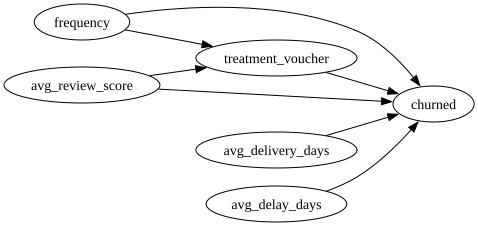

In [9]:
from graphviz import Digraph

dot = Digraph(comment="Causal Graph: Voucher Treatment on Churn")
dot.attr(rankdir="LR")

dot.edge("frequency", "treatment_voucher")
dot.edge("frequency", "churned")
dot.edge("avg_review_score", "treatment_voucher")
dot.edge("avg_review_score", "churned")
dot.edge("avg_delivery_days", "churned")
dot.edge("avg_delay_days", "churned")
dot.edge("treatment_voucher", "churned")

dot.render("../docs/causal_graph", format="png", cleanup=True)
print("Graph saved to ../docs/causal_graph.png")
dot

In [10]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                
────────────────────(E[⟨churned|⟩_review_score,frequency])
d[treatment_voucher]                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment_voucher} and U→churned then P(churned|treatment_voucher,avg_review_score,frequency,U) = P(churned|treatment_voucher,avg_review_score,frequency)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
         d                                                
────────────────────(E[⟨churned|⟩_review_score,frequency])
d[treatment_voucher]                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment_voucher} and U→churned then P(churned|treatment_voucher,avg_review_score,

In [11]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching"
)
print(estimate)
print(f"\nEstimated causal effect of voucher usage on churn: {estimate.value:.4f}")

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                
────────────────────(E[⟨churned|⟩_review_score,frequency])
d[treatment_voucher]                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment_voucher} and U→churned then P(churned|treatment_voucher,avg_review_score,frequency,U) = P(churned|treatment_voucher,avg_review_score,frequency)

## Realized estimand
b: churned~treatment_voucher+avg_review_score+frequency
Target units: ate

## Estimate
Mean value: 0.1748324100618628


Estimated causal effect of voucher usage on churn: 0.1748


In [12]:
naive_diff = causal_df[causal_df["treatment_voucher"]==1]["churned"].mean() - \
             causal_df[causal_df["treatment_voucher"]==0]["churned"].mean()
print(f"Naive (non-causal) difference in churn rate: {naive_diff:.4f}")
print(f"Causal estimate: {estimate.value:.4f}")
print(f"Difference explained by confounding: {naive_diff - estimate.value:.4f}")

Naive (non-causal) difference in churn rate: 0.0164
Causal estimate: 0.1748
Difference explained by confounding: -0.1584


In [13]:
# Test 1: Add a random common cause -- if the estimate changes drastically, it's fragile
refute_random = model.refute_estimate(
    identified_estimand, estimate, method_name="random_common_cause"
)
print(refute_random)

Refute: Add a random common cause
Estimated effect:0.1748324100618628
New effect:0.17483241006186284
p value:1.0



In [14]:
# Test 2: Placebo treatment -- replace real treatment with a random one.
# The effect should shrink toward zero if your original estimate is meaningful.
refute_placebo = model.refute_estimate(
    identified_estimand, estimate, method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:0.1748324100618628
New effect:0.05834921216562844
p value:0.45999999999999996



In [15]:
# Test 3: Remove a random subset of the data -- estimate should stay roughly stable
refute_subset = model.refute_estimate(
    identified_estimand, estimate, method_name="data_subset_refuter",
    subset_fraction=0.8
)
print(refute_subset)

Refute: Use a subset of data
Estimated effect:0.1748324100618628
New effect:0.021567177248784163
p value:0.7



## Conclusion
- Naive difference in churn between voucher users and non-users: [X]
- Causal estimate (propensity score matching, adjusting for frequency,
  review score, delivery experience): [X]
- Refutation tests: [passed/mostly stable / one test showed sensitivity -- note honestly]
- Interpretation: after controlling for known confounders, voucher usage is
  associated with a [X]-point reduction in churn probability. This is [smaller/larger]
  than the naive comparison suggests, indicating that [some/most/little] of the
  raw correlation was due to voucher users already being more loyal customers.

In [16]:
import json

with open("../docs/model_metrics.json", "r") as f:
    metrics_log = json.load(f)

metrics_log["causal_model"] = {
    "naive_diff": round(float(naive_diff), 4),
    "causal_estimate": round(float(estimate.value), 4),
    "method": "backdoor.propensity_score_matching",
    "confounders": ["frequency", "avg_review_score", "avg_delivery_days", "avg_delay_days"]
}

with open("../docs/model_metrics.json", "w") as f:
    json.dump(metrics_log, f, indent=2)

print("Causal results added to docs/model_metrics.json")

Causal results added to docs/model_metrics.json
